# Imports

In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

# Model And Data Loading

In [ ]:
# model = joblib.load('../models/random_forest.pkl')
model = joblib.load('../models/XGBoost_v2.pkl')
# model = joblib.load('../models/best_model_v1.pkl')

X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet').squeeze()

FileNotFoundError: [Errno 2] No such file or directory: '../models/best_model_v1.pkl'

# Metrics

In [ ]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, pred))
print('ROC-AUC: ', roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.66      0.71      0.69      2757
           1       0.61      0.55      0.58      2243

    accuracy                           0.64      5000
   macro avg       0.63      0.63      0.63      5000
weighted avg       0.64      0.64      0.64      5000

ROC-AUC:  0.6705583533892814


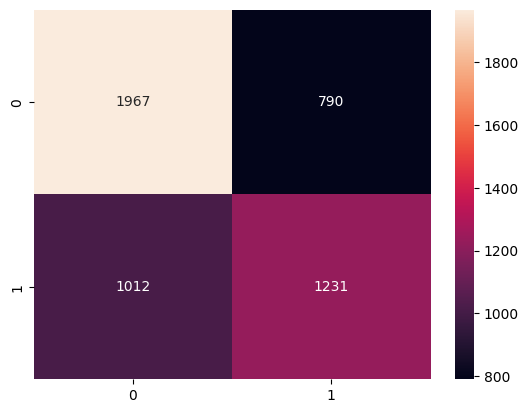

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
plt.show()

In [ ]:
confusion_matrix(y_test, pred)

array([[1967,  790],
       [1012, 1231]])

# Feature Importance

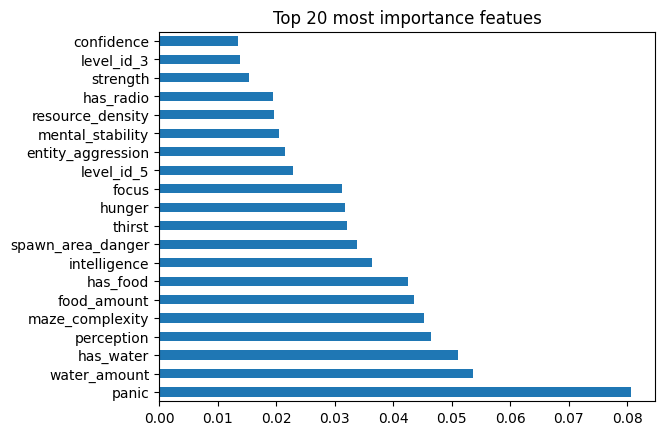

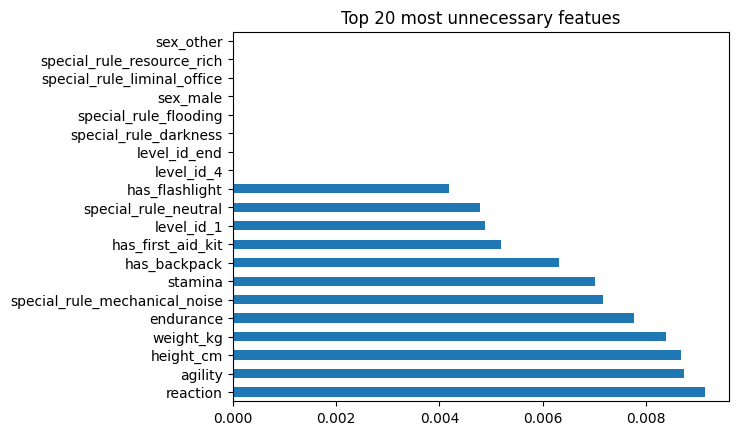

In [ ]:
importances = pd.Series(model.feature_importances_, index=X_test.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title('Top 20 most importance featues')
plt.show()
importances.sort_values(ascending=False).tail(20).plot(kind='barh')
plt.title('Top 20 most unnecessary featues')
plt.show()

In [ ]:
# df_temp = pd.read_csv('../data/raw/backrooms_survival_v4.csv')

# dataframe_for_pydantic = df_temp[['fatigue', 'panic', 'thirst', 'reaction', 'hunger', 'survived_24h']]
# dataframe_for_pydantic.to_csv('../data/processed/streamlit_test.csv', sep=',', index=False)

In [ ]:
# df_streamlit = pd.read_csv('../data/processed/streamlit_test.csv')
# df_streamlit.describe()